### **AFM 244 - S26 - Week 11 - Team Activity**

# Tanner Vo Tran - 21147574

# Jenny Vuong - 21123249

Company: Costco

Dummy Variables: Holiday Season & summer

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format='{:.2f}'.format

costco = pd.read_csv('costco_quarterly_revenue_2010_2025.csv')
costco['quarter_end_date'] = pd.to_datetime(costco['quarter_end_date'])
display(costco)

,fiscal_year,fiscal_quarter,quarter_end_date,revenue_usd_millions
0,FY2011,Q4,2011-08-31,28178
1,FY2012,Q1,2011-11-30,21628
2,FY2012,Q2,2012-02-29,22967
3,FY2012,Q3,2012-05-31,22324
4,FY2012,Q4,2012-08-31,32218
5,FY2013,Q1,2012-11-30,23715
6,FY2013,Q2,2013-02-28,24871
7,FY2013,Q3,2013-05-31,24083
8,FY2013,Q4,2013-08-31,32487
9,FY2014,Q1,2013-11-30,25017


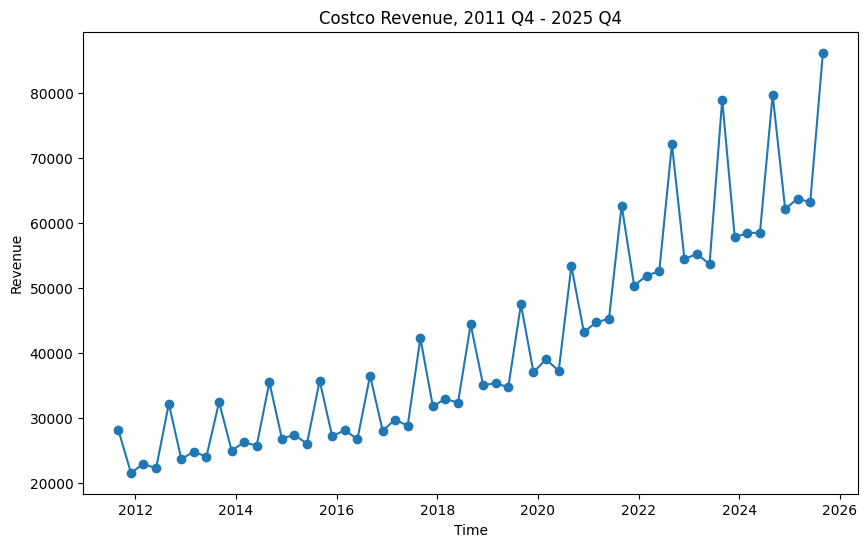

In [ ]:
# Visualize revenue over the years
plt.figure(figsize=(10,6))
plt.title('Costco Revenue, 2011 Q4 - 2025 Q4')
plt.xlabel('Time')
plt.ylabel('Revenue')

plt.plot(costco['quarter_end_date'], costco['revenue_usd_millions'], marker='o')


In [ ]:
# Adding in time as a variable
costco['time'] = range(1,len(costco)+1)
display(costco)

,fiscal_year,fiscal_quarter,quarter_end_date,revenue_usd_millions,time
0,FY2011,Q4,2011-08-31,28178,1
1,FY2012,Q1,2011-11-30,21628,2
2,FY2012,Q2,2012-02-29,22967,3
3,FY2012,Q3,2012-05-31,22324,4
4,FY2012,Q4,2012-08-31,32218,5
5,FY2013,Q1,2012-11-30,23715,6
6,FY2013,Q2,2013-02-28,24871,7
7,FY2013,Q3,2013-05-31,24083,8
8,FY2013,Q4,2013-08-31,32487,9
9,FY2014,Q1,2013-11-30,25017,10


## Introducing dummy variable

In [ ]:
# holiday_dv = holiday season
# Costco's Q1 runs from September to November which is their busiest foottraffic season
# And, the most holidays fall within this date range (e.g. halloween, thanksgiving, etc.)

costco['holiday_dv'] = np.where(costco['fiscal_quarter']=='Q1',1,0)
costco['holiday_interaction'] = costco['holiday_dv']*costco['time']
display(costco)

,fiscal_year,fiscal_quarter,quarter_end_date,revenue_usd_millions,time,holiday_dv,holiday_interaction
0,FY2011,Q4,2011-08-31,28178,1,0,0
1,FY2012,Q1,2011-11-30,21628,2,1,2
2,FY2012,Q2,2012-02-29,22967,3,0,0
3,FY2012,Q3,2012-05-31,22324,4,0,0
4,FY2012,Q4,2012-08-31,32218,5,0,0
5,FY2013,Q1,2012-11-30,23715,6,1,6
6,FY2013,Q2,2013-02-28,24871,7,0,0
7,FY2013,Q3,2013-05-31,24083,8,0,0
8,FY2013,Q4,2013-08-31,32487,9,0,0
9,FY2014,Q1,2013-11-30,25017,10,1,10


In [ ]:
# summer_dv = during Q4, revenue tends to spike

costco['summer_dv'] = np.where(costco['fiscal_quarter']=='Q4',1,0)

costco['summer_interaction'] = costco['summer_dv']*costco['time']
display(costco)

,fiscal_year,fiscal_quarter,quarter_end_date,revenue_usd_millions,time,holiday_dv,holiday_interaction,summer_dv,summer_interaction
0,FY2011,Q4,2011-08-31,28178,1,0,0,1,1
1,FY2012,Q1,2011-11-30,21628,2,1,2,0,0
2,FY2012,Q2,2012-02-29,22967,3,0,0,0,0
3,FY2012,Q3,2012-05-31,22324,4,0,0,0,0
4,FY2012,Q4,2012-08-31,32218,5,0,0,1,5
5,FY2013,Q1,2012-11-30,23715,6,1,6,0,0
6,FY2013,Q2,2013-02-28,24871,7,0,0,0,0
7,FY2013,Q3,2013-05-31,24083,8,0,0,0,0
8,FY2013,Q4,2013-08-31,32487,9,0,0,1,9
9,FY2014,Q1,2013-11-30,25017,10,1,10,0,0


## Model

In [ ]:
dt4training = costco[:int(0.75*len(costco))]
dt4testing = costco[int(0.75*len(costco)):]

display(dt4training)
display(dt4testing)

,fiscal_year,fiscal_quarter,quarter_end_date,revenue_usd_millions,time,holiday_dv,holiday_interaction,summer_dv,summer_interaction
0,FY2011,Q4,2011-08-31,28178,1,0,0,1,1
1,FY2012,Q1,2011-11-30,21628,2,1,2,0,0
2,FY2012,Q2,2012-02-29,22967,3,0,0,0,0
3,FY2012,Q3,2012-05-31,22324,4,0,0,0,0
4,FY2012,Q4,2012-08-31,32218,5,0,0,1,5
5,FY2013,Q1,2012-11-30,23715,6,1,6,0,0
6,FY2013,Q2,2013-02-28,24871,7,0,0,0,0
7,FY2013,Q3,2013-05-31,24083,8,0,0,0,0
8,FY2013,Q4,2013-08-31,32487,9,0,0,1,9
9,FY2014,Q1,2013-11-30,25017,10,1,10,0,0


,fiscal_year,fiscal_quarter,quarter_end_date,revenue_usd_millions,time,holiday_dv,holiday_interaction,summer_dv,summer_interaction
42,FY2022,Q2,2022-02-28,51904,43,0,0,0,0
43,FY2022,Q3,2022-05-31,52596,44,0,0,0,0
44,FY2022,Q4,2022-08-31,72091,45,0,0,1,45
45,FY2023,Q1,2022-11-30,54437,46,1,46,0,0
46,FY2023,Q2,2023-02-28,55266,47,0,0,0,0
47,FY2023,Q3,2023-05-31,53648,48,0,0,0,0
48,FY2023,Q4,2023-08-31,78939,49,0,0,1,49
49,FY2024,Q1,2023-11-30,57799,50,1,50,0,0
50,FY2024,Q2,2024-02-29,58442,51,0,0,0,0
51,FY2024,Q3,2024-05-31,58515,52,0,0,0,0


In [ ]:
# Model 1 = time
y = dt4training.loc[:,'revenue_usd_millions']

x1 = dt4training.loc[:,'time']
x1 = sm.add_constant(x1)

model1 = sm.OLS(y,x1).fit()
model1.params

,0
const,20435.43
time,618.05


In [ ]:
# Model 2 = time + holiday_dv
x2 = dt4training.loc[:,['time','holiday_dv','holiday_interaction']]
x2 = sm.add_constant(x2)

model2 = sm.OLS(y,x2).fit()
model2.params

,0
const,21271.35
time,615.64
holiday_dv,-3385.63
holiday_interaction,17.79


In [ ]:
# Model 3 = time + summer_dv
x3 = dt4training.loc[:,['time','summer_dv','summer_interaction']]
x3 = sm.add_constant(x3)

model3 = sm.OLS(y,x3).fit()
model3.params

,0
const,18538.39
time,581.38
summer_dv,6880.81
summer_interaction,160.61


In [ ]:
# Model 4 = time + holiday_dv + summer_dv
x4 = dt4training.loc[:,['time','holiday_dv','holiday_interaction','summer_dv','summer_interaction']]
x4 = sm.add_constant(x4)

model4 = sm.OLS(y,x4).fit()
model4.params

,0
const,19034.22
time,545.71
holiday_dv,-1148.50
holiday_interaction,87.72
summer_dv,6384.97
summer_interaction,196.28


Costco Quarterly Rev - **Model 1** = 20435 + 618.05 x time

Costco Quarterly Rev - **Model 2 **= 21271.35 + 615.64 x time - 3385.63 x holiday_dv + 17.79 x (time x holiday_dv)

Costco Quarterly Rev - **Model 3** = 18538.39 + 581.38 x time + 6880.81 x summer_dv + 160.61 x (time x summer_dv)

Costco Quarterly Rev - **Model 4** = 19034.22 + 545.71 x time - 1148.50 x holiday_dv + 87.72 x (holiday_dv x time) + 6384.97 x summer_dv + 196.28 x (summer_dv x time)


## MAPE Score

In [ ]:
# Model 1
x1_test = dt4testing.loc[:, 'time']
x1_test = sm.add_constant(x1_test)

model_assessment = dt4testing.copy()
model_assessment['model1_predicted_revenue'] = model1.predict(x1_test)
model_assessment['model1_pct_error'] = abs(((model_assessment['revenue_usd_millions'])-(model_assessment['model1_predicted_revenue']
                                                                     ))/model_assessment['revenue_usd_millions'])

# Model 2
x2_test = dt4testing.loc[:, ['time','holiday_dv','holiday_interaction']]
x2_test = sm.add_constant(x2_test)

model_assessment['model2_predicted_revenue'] = model2.predict(x2_test)
model_assessment['model2_pct_error'] = abs(((model_assessment['revenue_usd_millions'])-(model_assessment['model2_predicted_revenue']
                                                                     ))/model_assessment['revenue_usd_millions'])

# Model 3
x3_test = dt4testing.loc[:, ['time','summer_dv','summer_interaction']]
x3_test = sm.add_constant(x3_test)

model_assessment['model3_predicted_revenue'] = model3.predict(x3_test)
model_assessment['model3_pct_error'] = abs(((model_assessment['revenue_usd_millions'])-(model_assessment['model3_predicted_revenue']
                                                                     ))/model_assessment['revenue_usd_millions'])

# Model 3
x4_test = dt4testing.loc[:, ['time','holiday_dv','holiday_interaction','summer_dv','summer_interaction']]
x4_test = sm.add_constant(x4_test)

model_assessment['model4_predicted_revenue'] = model4.predict(x4_test)
model_assessment['model4_pct_error'] = abs(((model_assessment['revenue_usd_millions'])-(model_assessment['model4_predicted_revenue']
                                                                     ))/model_assessment['revenue_usd_millions'])

display(model_assessment)

,fiscal_year,fiscal_quarter,quarter_end_date,revenue_usd_millions,time,holiday_dv,holiday_interaction,summer_dv,summer_interaction,model1_predicted_revenue,model1_pct_error,model2_predicted_revenue,model2_pct_error,model3_predicted_revenue,model3_pct_error,model4_predicted_revenue,model4_pct_error
42,FY2022,Q2,2022-02-28,51904,43,0,0,0,0,47011.52,0.09,47744.01,0.08,43537.58,0.16,42499.88,0.18
43,FY2022,Q3,2022-05-31,52596,44,0,0,0,0,47629.57,0.09,48359.65,0.08,44118.95,0.16,43045.59,0.18
44,FY2022,Q4,2022-08-31,72091,45,0,0,1,45,48247.62,0.33,48975.29,0.32,58808.78,0.18,58808.78,0.18
45,FY2023,Q1,2022-11-30,54437,46,1,46,0,0,48865.67,0.10,47023.69,0.14,45281.71,0.17,47023.69,0.14
46,FY2023,Q2,2023-02-28,55266,47,0,0,0,0,49483.72,0.10,50206.58,0.09,45863.08,0.17,44682.73,0.19
47,FY2023,Q3,2023-05-31,53648,48,0,0,0,0,50101.77,0.07,50822.22,0.05,46444.46,0.13,45228.44,0.16
48,FY2023,Q4,2023-08-31,78939,49,0,0,1,49,50719.82,0.36,51437.87,0.35,61776.75,0.22,61776.75,0.22
49,FY2024,Q1,2023-11-30,57799,50,1,50,0,0,51337.87,0.11,49557.43,0.14,47607.21,0.18,49557.43,0.14
50,FY2024,Q2,2024-02-29,58442,51,0,0,0,0,51955.92,0.11,52669.15,0.10,48188.59,0.18,46865.58,0.20
51,FY2024,Q3,2024-05-31,58515,52,0,0,0,0,52573.96,0.10,53284.80,0.09,48769.97,0.17,47411.29,0.19


In [ ]:
model_assessment['model1_pct_error'].mean()

np.float64(0.17132791329207167)

In [ ]:
model_assessment['model2_pct_error'].mean()

np.float64(0.16833576257113197)

In [ ]:
model_assessment['model3_pct_error'].mean()

np.float64(0.18080529471453882)

In [ ]:
model_assessment['model4_pct_error'].mean()

np.float64(0.1859096766974408)

Model 1 MAPE = 17.1%

Model 2 MAPE = 16.8% - *best MAPE score, will estimate revenue will this model*

Model 3 MAPE = 18.0%

Model 4 MAPE = 18.6%

## Estimate

In [ ]:
x2_test = costco.loc[:,['time','holiday_dv','holiday_interaction']]
x2_test = sm.add_constant(x2_test)

model2.get_prediction(x2_test).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,21886.99,1911.46,19394.01,24379.98,14433.92,29340.07
1,19152.59,3037.76,15190.65,23114.53,11088.46,27216.73
2,23118.28,1773.42,20805.34,25431.22,15723.48,30513.08
3,23733.92,1705.99,21508.91,25958.93,16366.16,31101.69
4,24349.57,1639.81,22210.87,26488.26,17007.40,31691.73
5,21686.33,2618.22,18271.56,25101.09,13876.47,29496.19
6,25580.85,1511.83,23609.08,27552.62,18285.57,32876.14
7,26196.50,1450.41,24304.83,28088.16,18922.45,33470.54
8,26812.14,1391.01,24997.95,28626.33,19557.86,34066.42
9,24220.06,2238.19,21300.95,27139.17,16613.85,31826.28


In [ ]:
next4quarters = pd.DataFrame({'time':[61,62,63,64],'holiday_dv':[0,1,0,0]})
next4quarters['holiday_interaction'] = next4quarters['holiday_dv'] * next4quarters['time']
next4quarters = sm.add_constant(next4quarters)
forecast = model2.predict(next4quarters)

print(forecast)

0   58825.58
1   57158.64
2   60056.87
3   60672.51
dtype: float64


From Model 2, the predicted revenue for...

*   2026 Q1 = $58,825.58

*   2026 Q2 = $57,158.64

*   2026 Q3 = $60,056.87

*   2026 Q4 = $60,672.51
